# LeetCode #543: Diameter of Binary Tree

https://leetcode.com/problems/diameter-of-binary-tree/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (height per node)** | $O(n^2)$ | $O(h)$ |
| **Optimal: DFS Post-order ★** | $O(n)$ | $O(h)$ |

---

## Understanding the Methods

### Brute Force (height per node)
For each node, compute the height of its left and right subtrees separately and add them to get the candidate diameter. Computing height from scratch for each of the $n$ nodes costs $O(n)$, giving $O(n^2)$ total.

### Optimal: DFS Post-order ★
Post-order DFS returns the depth of each subtree. At each node, the diameter candidate through that node = leftDepth + rightDepth. Track the global maximum. Return `max(left, right) + 1` upward. Each node is visited once: $O(n)$ time, $O(h)$ stack space.

**Why this is better than Brute Force:** By returning depth from the same recursive call that updates the diameter, we avoid redundant height computations for each node.

**Constraints:**
* The number of nodes in the tree is in the range $[1, 10^4]$
* $-100 \le \text{Node.val} \le 100$


## Solutions

### C#

In [ ]:
public int DiameterOfBinaryTree(TreeNode root) {
    int diameter = 0;
    int Depth(TreeNode node) {
        if (node == null) return 0;
        int l = Depth(node.left), r = Depth(node.right);
        // Diameter through this node = path length crossing left + right subtrees
        diameter = Math.Max(diameter, l + r);
        return Math.Max(l, r) + 1;
    }
    Depth(root);
    return diameter;
}

### Python

In [ ]:
def diameter_of_binary_tree(root) -> int:
    diameter = 0

    def depth(node) -> int:
        nonlocal diameter
        if not node:
            return 0
        l, r = depth(node.left), depth(node.right)
        # Diameter through this node = path length crossing left + right subtrees
        diameter = max(diameter, l + r)
        return max(l, r) + 1

    depth(root)
    return diameter

### Go

In [ ]:
func diameterOfBinaryTree(root *TreeNode) int {
    diameter := 0
    var depth func(*TreeNode) int
    depth = func(node *TreeNode) int {
        if node == nil { return 0 }
        l, r := depth(node.Left), depth(node.Right)
        // Diameter through this node = path length crossing left + right subtrees
        if l+r > diameter { diameter = l + r }
        if l > r { return l + 1 }
        return r + 1
    }
    depth(root)
    return diameter
}

### Rust

In [ ]:
pub fn diameter_of_binary_tree(root: Option<Box<TreeNode>>) -> i32 {
    fn depth(node: &Option<Box<TreeNode>>, diameter: &mut i32) -> i32 {
        match node {
            None => 0,
            Some(n) => {
                let l = depth(&n.left, diameter);
                let r = depth(&n.right, diameter);
                // Diameter through this node = path length crossing left + right subtrees
                *diameter = (*diameter).max(l + r);
                l.max(r) + 1
            }
        }
    }
    let mut diameter = 0;
    depth(&root, &mut diameter);
    diameter
}

## Example Scenarios

**1. Common Case**
**Input:** `root = [1,2,3,4,5]`
Depths: node 4 → 1, node 5 → 1, node 2 → 2, node 3 → 1. At node 2: diameter candidate = 1+1=2. At node 1: diameter candidate = 2+1=3. Global max = 3.

**2. Slightly Complex**
**Input:** `root = [1,2,null,3,null,4,null,5]` (left-skewed with one branch)
Path 5→4→3→2→1 has length 4. But the diameter could go through a different root. In this case, the longest path has 4 edges (node 5 to node 1). Answer = 4.

**3. Edge Case: Time Factor**
**Input:** Complete binary tree with $n = 10^4$ nodes
Every node is visited exactly once. At the deepest level, both children return depth 1 and their parent computes diameter = 2. This propagates upward. $O(n)$ visits required — no shortcutting possible.

**4. Edge Case: Space Factor**
**Input:** Right-skewed tree `[1,null,2,null,...,null,10000]`
The recursion stack reaches depth $h = n = 10^4$. Diameter = path from the deepest node back through the root = $n-1 = 9999$ edges. Stack space peaks at $O(h) = O(n)$.

**5. Almost-Impossible but Plausible**
**Input:** `root = [1]` (single node)
Left and right depths both return 0. Diameter candidate = 0+0 = 0. Global max stays 0. Correct: a single node has diameter 0 (no edges).


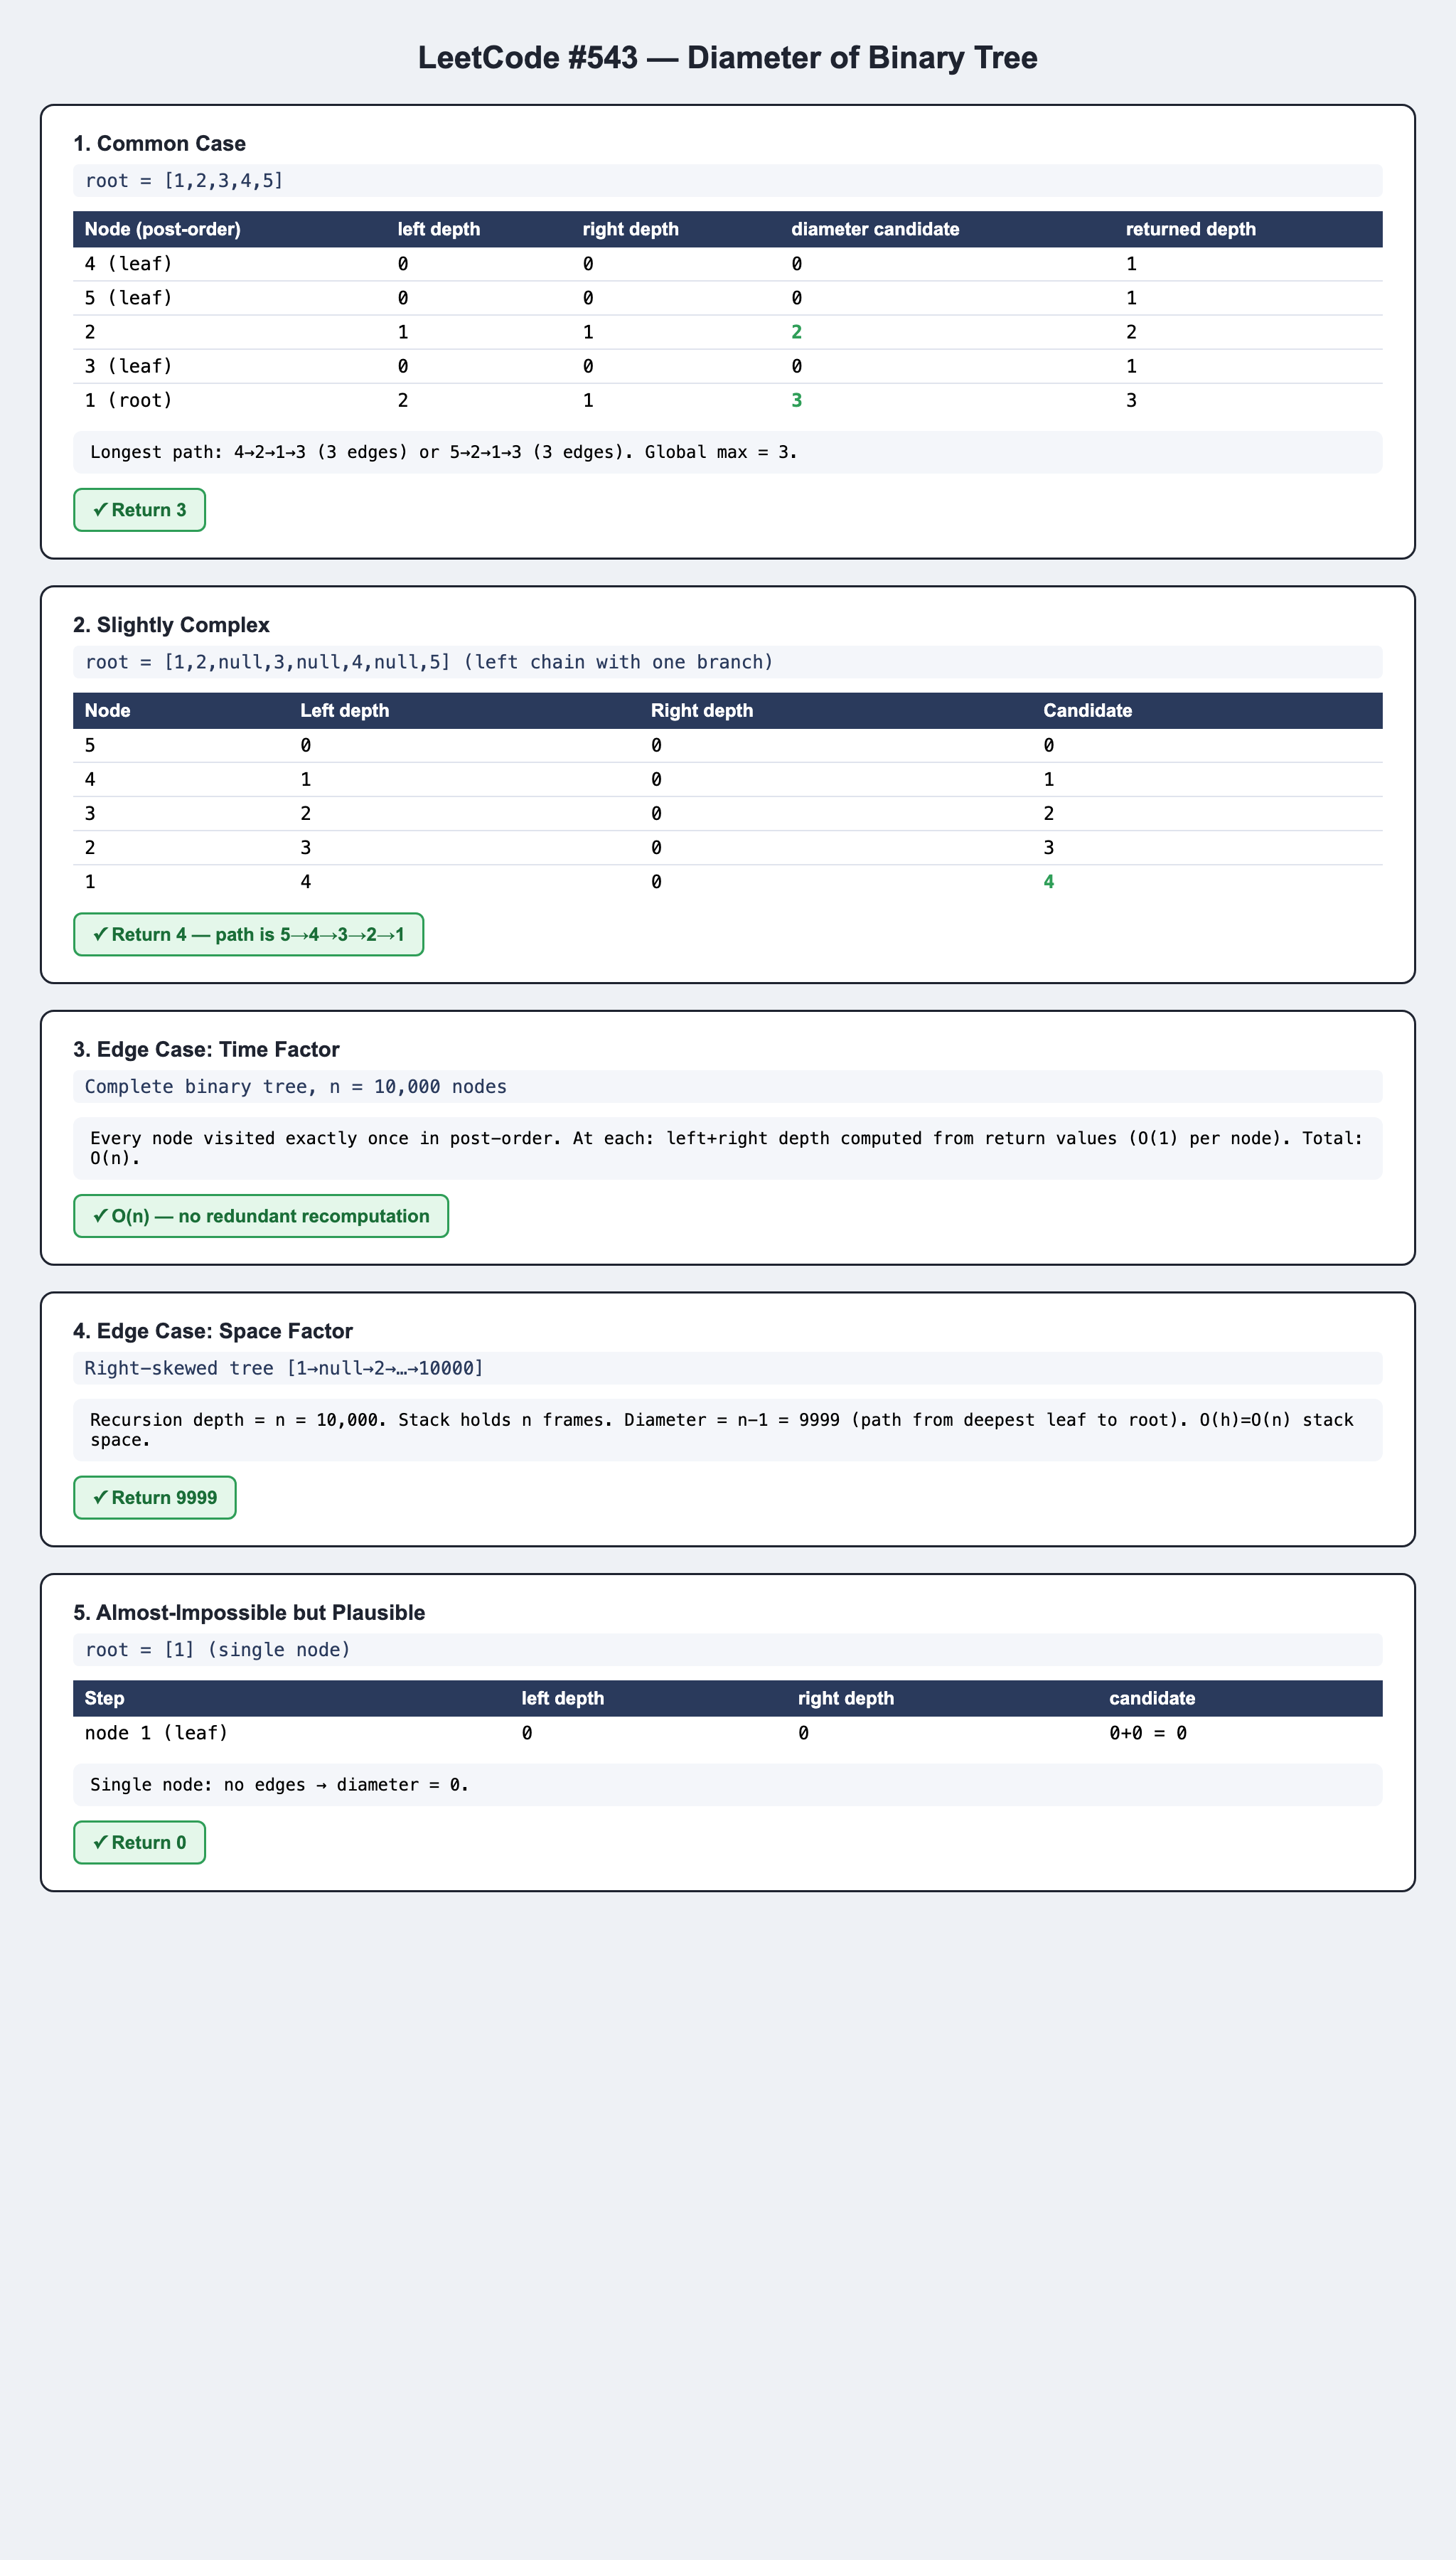